# Fraud Detection 

In [1]:
# ─────────────────────────────────────────────
# CELL 1 — Setup & Imports
# ─────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)


try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed. Skipping XGBoost model.')

print('Setup complete')

Setup complete


In [2]:
# ─────────────────────────────────────────────
# CELL 2 — Load Data
# ─────────────────────────────────────────────
DATA_PATH = 'Fraud.csv'
assert os.path.exists(DATA_PATH), 'Dataset not found — place Fraud.csv in the same directory'

df = pd.read_csv(DATA_PATH)
print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loaded dataset: 6,362,620 rows × 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — Basic Overview
# ─────────────────────────────────────────────
print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['isFraud'].value_counts())
print(f'\nFraud rate: {df["isFraud"].mean():.4%}')

Shape: (6362620, 11)

Column dtypes:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Null counts:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%


##### How fraud probability changes with transaction amount

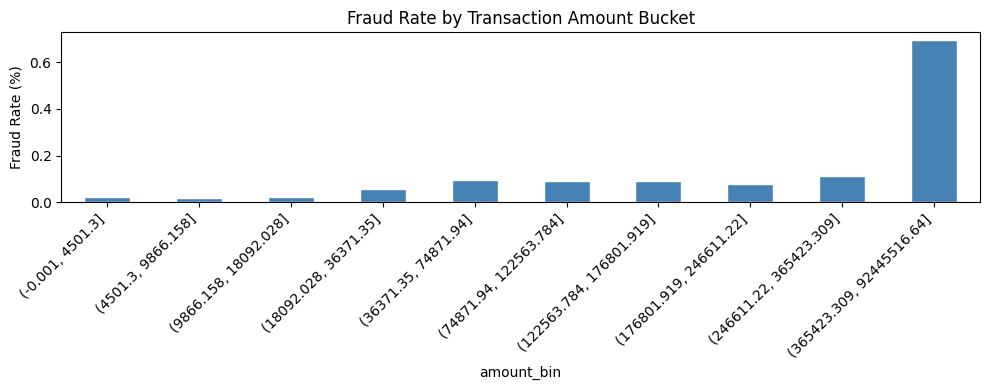

Higher-value transactions have significantly higher fraud rates.


In [4]:
# ─────────────────────────────────────────────
# CELL 4 — Fraud Rate by Amount Bucket
# ─────────────────────────────────────────────
df['amount_bin'] = pd.qcut(df['amount'], q=10, duplicates='drop')
fraud_rate = df.groupby('amount_bin', observed=True)['isFraud'].mean() * 100

plt.figure(figsize=(10, 4))
fraud_rate.plot(kind='bar', color='steelblue', edgecolor='white')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Transaction Amount Bucket')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Higher-value transactions have significantly higher fraud rates.')

In [5]:
# ─────────────────────────────────────────────
# CELL 5 — Merchant Zero Balance Check
# ─────────────────────────────────────────────
print('Null check across all columns:')
print(df.isnull().sum())

# Merchant transactions: destination name starts with 'M'
merchant_txns = df[df['nameDest'].str.startswith('M')]
print(f'\nMerchant transactions: {len(merchant_txns):,}')
display(merchant_txns[['oldbalanceDest', 'newbalanceDest']].describe())

print("""
Finding: All 2.15M merchant destination balances are exactly 0.
Reason : Merchant balances were never tracked in this simulation —
         merchants are money-sink endpoints. These zeros are
         structurally valid, NOT missing data requiring imputation.
Action : No imputation performed.
""")

Null check across all columns:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
amount_bin        0
dtype: int64

Merchant transactions: 2,151,495


,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0



Finding: All 2.15M merchant destination balances are exactly 0.
Reason : Merchant balances were never tracked in this simulation —
         merchants are money-sink endpoints. These zeros are
         structurally valid, NOT missing data requiring imputation.
Action : No imputation performed.



In [6]:
# ─────────────────────────────────────────────
# CELL 6 — Class Imbalance Overview
# ─────────────────────────────────────────────
total_txns   = len(df)
fraud_txns   = df['isFraud'].sum()
fraud_rate   = fraud_txns / total_txns
flagged_pct  = df['isFlaggedFraud'].sum() / total_txns * 100

print(f'Total transactions      : {total_txns:,}')
print(f'Fraud transactions      : {fraud_txns:,}')
print(f'Overall fraud rate      : {fraud_rate:.4%}')
print(f'Rule-based flagged rate : {flagged_pct:.4f}%')
print()
print('Rule-based system catches <0.001% — ML is needed.')

Total transactions      : 6,362,620
Fraud transactions      : 8,213
Overall fraud rate      : 0.1291%
Rule-based flagged rate : 0.0003%

Rule-based system catches <0.001% — ML is needed.


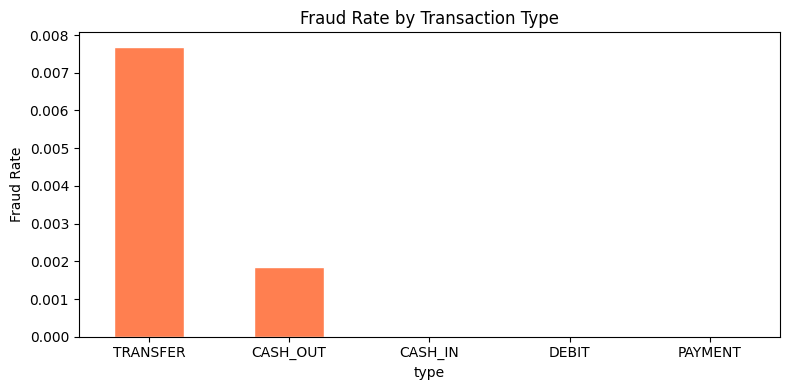

Only TRANSFER and CASH_OUT have non-zero fraud — key insight for feature engineering.


In [7]:
# ─────────────────────────────────────────────
# CELL 7 — Fraud Rate by Transaction Type
# ─────────────────────────────────────────────
type_fraud = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
type_fraud.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Fraud Rate by Transaction Type')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Only TRANSFER and CASH_OUT have non-zero fraud — key insight for feature engineering.')

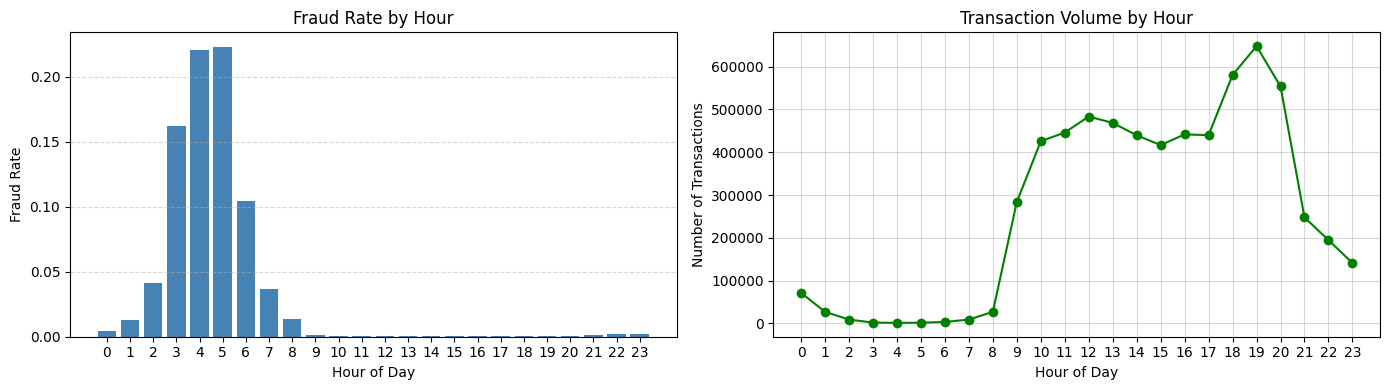

Fraud rate peaks between 2–5 AM (off-peak hours). is_night feature is well-motivated.


In [8]:
# ─────────────────────────────────────────────
# CELL 8 — Time-Based Analysis
# ─────────────────────────────────────────────
df['hour'] = df['step'] % 24
df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

hourly_stats = (
    df.groupby('hour')
      .agg(
          total_transactions=('isFraud', 'count'),
          fraud_transactions=('isFraud', 'sum'),
          fraud_rate=('isFraud', 'mean')
      )
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(hourly_stats['hour'], hourly_stats['fraud_rate'], color='steelblue')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_title('Fraud Rate by Hour')
axes[0].set_xticks(range(0, 24))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].plot(hourly_stats['hour'], hourly_stats['total_transactions'], marker='o', color='green')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_title('Transaction Volume by Hour')
axes[1].set_xticks(range(0, 24))
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.show()

print('Fraud rate peaks between 2–5 AM (off-peak hours). is_night feature is well-motivated.')

Amount statistics:
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


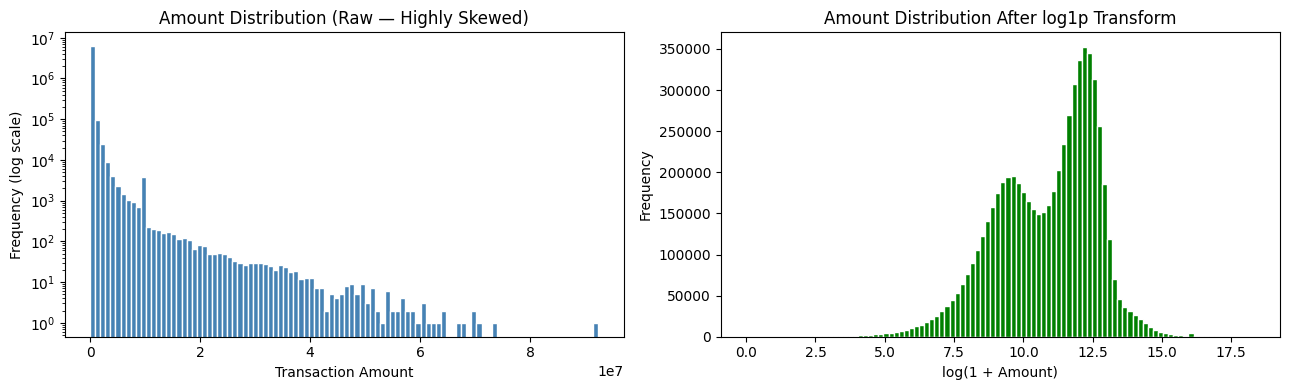

99th percentile threshold: 1,615,979.47
is_high_amount
0    6298993
1      63627
Name: count, dtype: int64


In [9]:
# ─────────────────────────────────────────────
# CELL 9 — Outlier & Skewness Handling
# ─────────────────────────────────────────────
print('Amount statistics:')
print(df['amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['amount'], bins=100, log=True, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Amount Distribution (Raw — Highly Skewed)')

axes[1].hist(np.log1p(df['amount']), bins=100, color='green', edgecolor='white')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Amount Distribution After log1p Transform')

plt.tight_layout()
plt.show()

# Log transform
df['log_amount'] = np.log1p(df['amount'])

# High-amount binary flag (top 1%)
p99 = df['amount'].quantile(0.99)
df['is_high_amount'] = (df['amount'] > p99).astype(int)
print(f'99th percentile threshold: {p99:,.2f}')
print(df['is_high_amount'].value_counts())

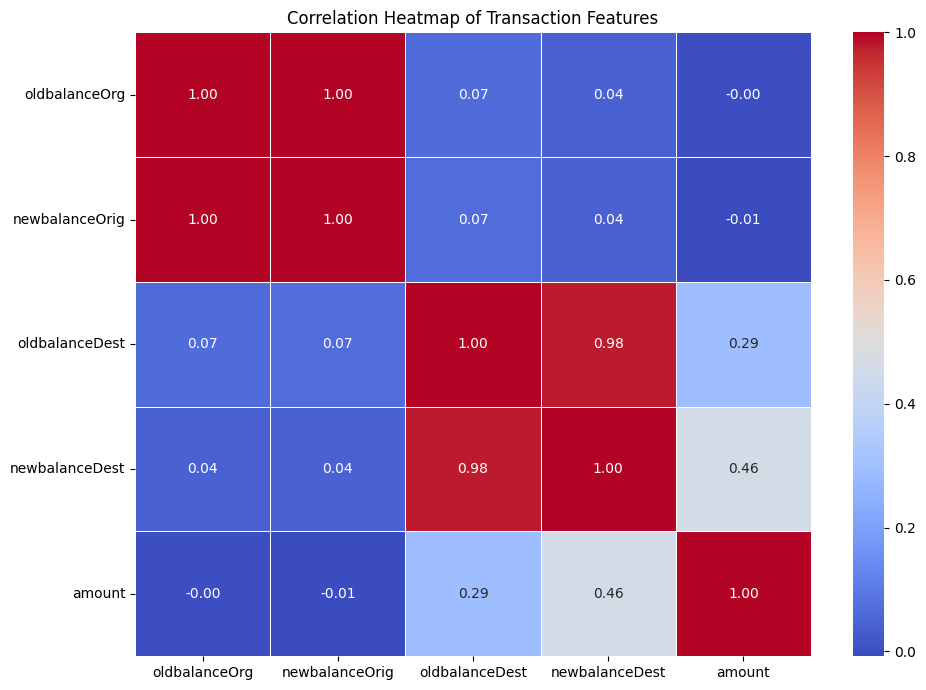


Finding: High multicollinearity between old/new balance columns.
Fix    : Replace raw balance columns with balance DIFFERENCES
         to remove redundancy and improve model stability.



In [10]:
# ─────────────────────────────────────────────
# CELL 10 — Correlation Heatmap
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr_cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'amount']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Transaction Features')
plt.tight_layout()
plt.show()

print("""
Finding: High multicollinearity between old/new balance columns.
Fix    : Replace raw balance columns with balance DIFFERENCES
         to remove redundancy and improve model stability.
""")

### Feature Engineering & Data Cleaning

In [11]:
# ─────────────────────────────────────────────
# CELL 11 — Feature Engineering
# ─────────────────────────────────────────────

# Balance difference features (replace correlated raw balances)
df['balance_diff_orig'] = df['oldbalanceOrg']   - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest']  - df['oldbalanceDest']

# Extra fraud signal: origin balance fully drained to zero
df['orig_balance_zero_after'] = (df['newbalanceOrig'] == 0).astype(int)

# Drop raw correlated balance columns
df = df.drop(columns=['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'])

# Drop amount_bin (temporary EDA column)
df.drop(columns=['amount_bin'], errors='ignore', inplace=True)


print('Features after engineering:')
print(df.columns.tolist())

Features after engineering:
['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud', 'hour', 'is_night', 'log_amount', 'is_high_amount', 'balance_diff_orig', 'balance_diff_dest', 'orig_balance_zero_after']


In [12]:
# ─────────────────────────────────────────────
# CELL 12 — Encoding (FIX: OneHot instead of LabelEncoder)
# ─────────────────────────────────────────────

# FIX: LabelEncoder assigns false ordinal relationships to transaction types
# (TRANSFER=4 implies it is 4x larger than CASH_IN=0 — meaningless!)
# Correct approach: OneHotEncoding via pd.get_dummies

type_dummies = pd.get_dummies(df['type'], prefix='type', drop_first=True)
# drop_first=True removes one category to avoid multicollinearity (dummy trap)
# Resulting columns: type_CASH_OUT, type_DEBIT, type_PAYMENT, type_TRANSFER
df = pd.concat([df, type_dummies], axis=1)
df.drop(columns=['type', 'nameOrig', 'nameDest', 'amount'], inplace=True)

print('Encoded transaction types:')
print(type_dummies.head())
print(f'\nFinal feature set shape: {df.shape}')
print('Columns:', df.columns.tolist())

Encoded transaction types:
   type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER
0          False       False          True          False
1          False       False          True          False
2          False       False         False           True
3           True       False         False          False
4          False       False          True          False

Final feature set shape: (6362620, 14)
Columns: ['step', 'isFraud', 'isFlaggedFraud', 'hour', 'is_night', 'log_amount', 'is_high_amount', 'balance_diff_orig', 'balance_diff_dest', 'orig_balance_zero_after', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [13]:
print(df.head())

   step  isFraud  isFlaggedFraud  hour  is_night  log_amount  is_high_amount  \
0     1        0               0     1         1    9.194276               0   
1     1        0               0     1         1    7.531166               0   
2     1        1               0     1         1    5.204007               0   
3     1        1               0     1         1    5.204007               0   
4     1        0               0     1         1    9.364703               0   

   balance_diff_orig  balance_diff_dest  orig_balance_zero_after  \
0            9839.64                0.0                        0   
1            1864.28                0.0                        0   
2             181.00                0.0                        1   
3             181.00           -21182.0                        1   
4           11668.14                0.0                        0   

   type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER  
0          False       False          True        

### Train / Validation / Test Split

In [14]:
# ─────────────────────────────────────────────
# CELL 13 — Train / Val / Test Split (FIX: added validation set)
# ─────────────────────────────────────────────

X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud'].values

# Step 1: Split off 20% as final test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Step 2: From remaining 80%, split off 15% as validation set
# (for threshold tuning — never touch test until final evaluation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42
)

print(f'Train set      : {X_train.shape}  | Fraud rate: {y_train.mean():.4%}')
print(f'Validation set : {X_val.shape}    | Fraud rate: {y_val.mean():.4%}')
print(f'Test set       : {X_test.shape}   | Fraud rate: {y_test.mean():.4%}')

# FIX: RobustScaler — fit ONLY on train, transform val and test
scaler = RobustScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns

X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  # fit + transform
X_val[num_cols]   = scaler.transform(X_val[num_cols])        # transform only
X_test[num_cols]  = scaler.transform(X_test[num_cols])       # transform only

# Save scaler immediately
joblib.dump(scaler, 'fraud_scaler.pkl')
print('\nScaler saved → fraud_scaler.pkl')

Train set      : (4326581, 12)  | Fraud rate: 0.1291%
Validation set : (763515, 12)    | Fraud rate: 0.1291%
Test set       : (1272524, 12)   | Fraud rate: 0.1291%

Scaler saved → fraud_scaler.pkl


### Logistic Regression — Hyperparameter Tuning

In [16]:
# ─────────────────────────────────────────────
# CELL 15 — Sample for Hyperparameter Search
# ─────────────────────────────────────────────

# Use a 500K stratified sample to speed up the CV search
sample_size = 500_000
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train,
    train_size=sample_size,
    stratify=y_train,
    random_state=42
)
print(f'Sample size: {X_sample.shape[0]:,} | Fraud rate: {y_sample.mean():.4%}')

Sample size: 500,000 | Fraud rate: 0.1290%


In [17]:
# ─────────────────────────────────────────────
# CELL 16 — Base Model Definition
# ─────────────────────────────────────────────

base_lr = LogisticRegression(
    solver='saga',          # supports both L1 and L2, fast on large data
    max_iter=300,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

In [18]:
# ─────────────────────────────────────────────
# CELL 17 — Parameter Grid
# ─────────────────────────────────────────────

param_dist = {
    'C'       : np.logspace(-3, 2, 6),   # [0.001, 0.01, 0.1, 1, 10, 100]
    'penalty' : ['l2'],                  # l2 is smooth & works with saga
    'max_iter': [300, 500]
}

print('Parameter search space:')
for k, v in param_dist.items():
    print(f'  {k}: {v}')

Parameter search space:
  C: [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
  penalty: ['l2']
  max_iter: [300, 500]


In [19]:
# ─────────────────────────────────────────────
# CELL 18 — RandomizedSearchCV
# FIX 1: scoring changed from roc_auc → average_precision
#         (AUPRC is more informative for imbalanced fraud data)
# ─────────────────────────────────────────────

search = RandomizedSearchCV(
    base_lr,
    param_distributions=param_dist,
    n_iter=10,
    scoring='average_precision',   # FIX: was 'roc_auc' — AUPRC is stricter for imbalanced data
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print('Starting hyperparameter search on 500K sample...')
search.fit(X_sample, y_sample)

Starting hyperparameter search on 500K sample...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END ..................C=100.0, max_iter=300, penalty=l2; total time=  58.9s
[CV] END ..................C=100.0, max_iter=300, penalty=l2; total time=  59.7s
[CV] END ..................C=0.001, max_iter=300, penalty=l2; total time=  59.8s
[CV] END ..................C=100.0, max_iter=300, penalty=l2; total time=  60.0s
[CV] END ..................C=0.001, max_iter=300, penalty=l2; total time= 1.0min
[CV] END ...................C=10.0, max_iter=500, penalty=l2; total time= 1.6min
[CV] END ...................C=10.0, max_iter=500, penalty=l2; total time= 1.6min
[CV] END ...................C=10.0, max_iter=500, penalty=l2; total time= 1.6min
[CV] END ..................C=0.001, max_iter=300, penalty=l2; total time=  55.9s
[CV] END ...................C=10.0, max_iter=300, penalty=l2; total time=  55.5s
[CV] END ...................C=10.0, max_iter=300, penalty=l2; total time=  55.2s

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.e-03...e+01, 1.e+02]), 'max_iter': [300, 500], 'penalty': ['l2']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default v

In [20]:
# ─────────────────────────────────────────────
# CELL 19 — Verify & Apply Best Params
# FIX: Explicitly print and verify params before building final model
# (Prevents the param mismatch bug from original notebook)
# ─────────────────────────────────────────────

best_params = search.best_params_
print('Best parameters found:')
for k, v in best_params.items():
    print(f'  {k}: {v}')
print(f'Best CV AUPRC score: {search.best_score_:.4f}')

Best parameters found:
  penalty: l2
  max_iter: 500
  C: 0.1
Best CV AUPRC score: 0.6748


In [21]:
# ─────────────────────────────────────────────
# CELL 20 — Train Final LR Model on Full Training Data
# FIX: Explicitly unpack each parameter instead of **best_params
#      to avoid silent key mismatches
# ─────────────────────────────────────────────

best_lr = LogisticRegression(
    C            = best_params['C'],
    penalty      = best_params['penalty'],
    max_iter     = best_params['max_iter'],
    solver       ='saga',
    class_weight ='balanced',
    n_jobs       =-1,
    random_state =42,
    verbose =2
)

# Double-check the model config BEFORE fitting
print('Training model with these exact params:')
print(best_lr)

print('\nFitting on full training set (class_weight='balanced' handles imbalance)...')
best_lr.fit(X_train, y_train)
print('Training complete!')

# FIX: Save model immediately after training
joblib.dump(best_lr, 'fraud_lr_model.pkl')
print('Model saved → fraud_lr_model.pkl')

Training model with these exact params:
LogisticRegression(C=np.float64(0.1), class_weight='balanced', max_iter=500,
                   n_jobs=-1, penalty='l2', random_state=42, solver='saga',
                   verbose=2)

Fitting on full training set (class_weight='balanced' handles imbalance)...
Epoch 1, change: 1
Epoch 2, change: 0.24295299
Epoch 3, change: 0.13977014
Epoch 4, change: 0.09969394
Epoch 5, change: 0.077993315
Epoch 6, change: 0.063994026
Epoch 7, change: 0.054516097
Epoch 8, change: 0.047379548
Epoch 9, change: 0.041739248
Epoch 10, change: 0.037192914
Epoch 11, change: 0.033467026
Epoch 12, change: 0.030347093
Epoch 13, change: 0.027709048
Epoch 14, change: 0.02543495
Epoch 15, change: 0.023480806
Epoch 16, change: 0.021768156
Epoch 17, change: 0.020261764
Epoch 18, change: 0.018925827
Epoch 19, change: 0.017736757
Epoch 20, change: 0.016675858
Epoch 21, change: 0.015718964
Epoch 22, change: 0.014846763
Epoch 23, change: 0.014059343
Epoch 24, change: 0.013338398
Epo

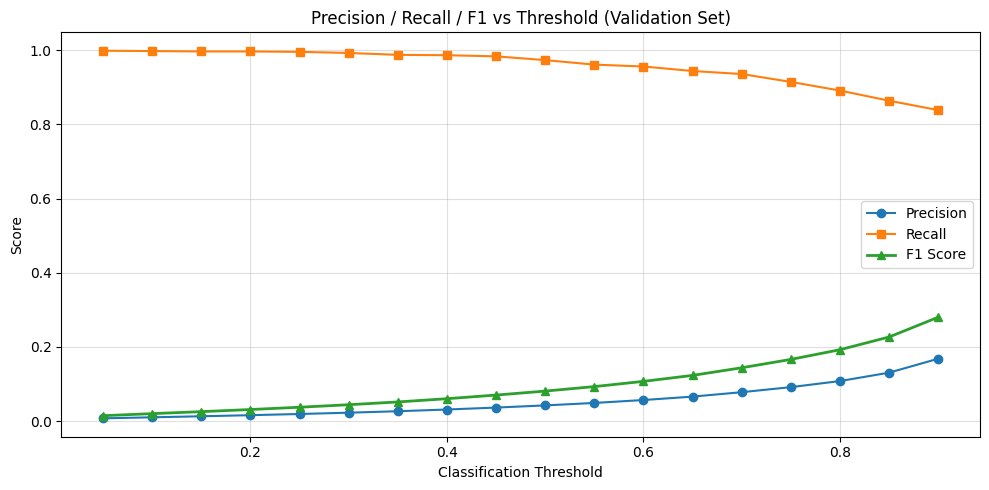


Best threshold by F1: 0.90
  Precision : 0.1681
  Recall    : 0.8387
  F1        : 0.2801


In [22]:
# ─────────────────────────────────────────────
# CELL 21 — Threshold Tuning on Validation Set
# FIX: Use validation set (not test set) to find optimal threshold
# Default threshold=0.5 gives Precision=2.7% — unacceptable in production
# ─────────────────────────────────────────────

y_prob_val = best_lr.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t   = (y_prob_val >= t).astype(int)
    prec       = precision_score(y_val, y_pred_t, zero_division=0)
    rec        = recall_score(y_val, y_pred_t, zero_division=0)
    f1         = f1_score(y_val, y_pred_t, zero_division=0)
    results.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1})

thresh_df = pd.DataFrame(results)

# Plot precision-recall tradeoff across thresholds
plt.figure(figsize=(10, 5))
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', marker='o')
plt.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    marker='s')
plt.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1 Score',  marker='^', linewidth=2)
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold (Validation Set)')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Best threshold by F1
best_row = thresh_df.loc[thresh_df['f1'].idxmax()]
BEST_THRESHOLD = best_row['threshold']
print(f'\nBest threshold by F1: {BEST_THRESHOLD:.2f}')
print(f'  Precision : {best_row["precision"]:.4f}')
print(f'  Recall    : {best_row["recall"]:.4f}')
print(f'  F1        : {best_row["f1"]:.4f}')

### Final Evaluation on Test Set

In [23]:
# ─────────────────────────────────────────────
# CELL 22 — Evaluate on Test Set Using Optimal Threshold
# ─────────────────────────────────────────────

def evaluate_model(name, y_true, y_pred, y_prob, threshold):
    """Print full evaluation metrics for a model."""
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'  Threshold: {threshold:.2f}')
    print(f'{"="*60}')
    print(f'  Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}')
    print(f'  AUPRC     : {average_precision_score(y_true, y_prob):.4f}')
    print(f'\nDetailed Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['Not Fraud', 'Fraud']))


# Get test probabilities
y_prob_test_lr = best_lr.predict_proba(X_test)[:, 1]

# Apply optimal threshold from validation
y_pred_test_lr = (y_prob_test_lr >= BEST_THRESHOLD).astype(int)

evaluate_model(
    'Logistic Regression (Optimal Threshold)',
    y_test, y_pred_test_lr, y_prob_test_lr, BEST_THRESHOLD
)


  Logistic Regression (Optimal Threshold)
  Threshold: 0.90
  Accuracy  : 0.9944
  Precision : 0.1690
  Recall    : 0.8558
  F1 Score  : 0.2822
  ROC-AUC   : 0.9963
  AUPRC     : 0.6505

Detailed Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00   1270881
       Fraud       0.17      0.86      0.28      1643

    accuracy                           0.99   1272524
   macro avg       0.58      0.93      0.64   1272524
weighted avg       1.00      0.99      1.00   1272524



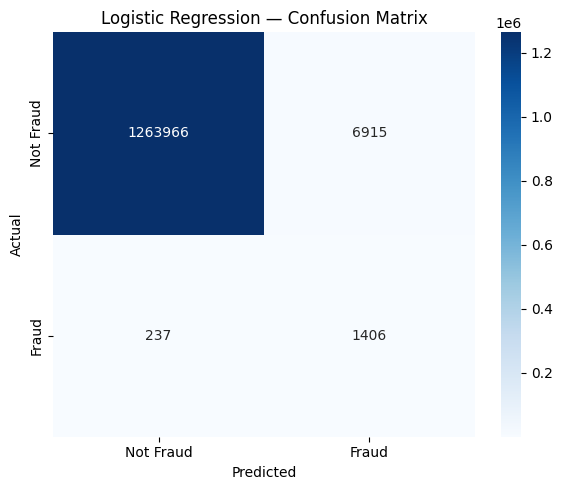

True Negatives  (correct non-fraud): 1,263,966
False Positives (false alarms)      : 6,915
False Negatives (missed fraud)      : 237
True Positives  (caught fraud)      : 1,406


In [24]:
# ─────────────────────────────────────────────
# CELL 23 — Confusion Matrix
# ─────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Not Fraud', 'Fraud'],
        yticklabels=['Not Fraud', 'Fraud']
    )
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f'True Negatives  (correct non-fraud): {tn:,}')
    print(f'False Positives (false alarms)      : {fp:,}')
    print(f'False Negatives (missed fraud)      : {fn:,}')
    print(f'True Positives  (caught fraud)      : {tp:,}')

plot_confusion_matrix(y_test, y_pred_test_lr, 'Logistic Regression — Confusion Matrix')

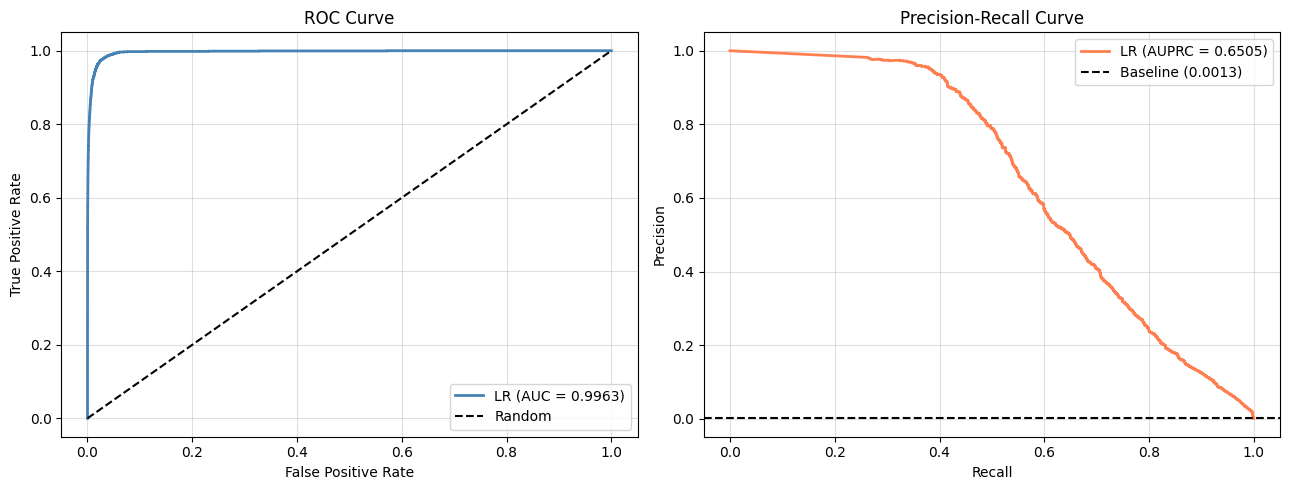

In [25]:
# ─────────────────────────────────────────────
# CELL 24 — ROC & Precision-Recall Curves
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test_lr)
auc_score   = roc_auc_score(y_test, y_prob_test_lr)
axes[0].plot(fpr, tpr, label=f'LR (AUC = {auc_score:.4f})', color='steelblue', lw=2)
axes[0].plot([0,1], [0,1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.4)

# Precision-Recall Curve
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob_test_lr)
auprc = average_precision_score(y_test, y_prob_test_lr)
axes[1].plot(rec_arr, prec_arr, label=f'LR (AUPRC = {auprc:.4f})', color='coral', lw=2)
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

### Random Forest Model

In [26]:
# ─────────────────────────────────────────────
# CELL 25 — Random Forest with RandomizedSearchCV
# (Uses raw unbalanced data — RF handles imbalance via class_weight)
# ─────────────────────────────────────────────

print('Training Random Forest...')

# Use smaller sample for RF hyperparameter search (RF is slow on 5M rows)
rf_sample_size = 500_000
X_rf_sample, _, y_rf_sample, _ = train_test_split(
    X_train, y_train,
    train_size=rf_sample_size,
    stratify=y_train,
    random_state=42
)

rf_param_dist = {
    'n_estimators'     : [100, 150, 200],
    'max_depth'        : [10, 15, 20, 25],
    'min_samples_split': [10, 20, 30],
    'max_features'     : ['sqrt']     # sqrt(n_features) columns per split — RF default
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_dist,
    n_iter=9,
    scoring='average_precision',   # consistent with LR search
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_rf_sample, y_rf_sample)

print('\nBest RF parameters:')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best CV AUPRC: {rf_search.best_score_:.4f}')

Training Random Forest...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best RF parameters:
  n_estimators: 150
  min_samples_split: 20
  max_features: sqrt
  max_depth: 25
Best CV AUPRC: 0.9242


In [27]:
# ─────────────────────────────────────────────
# CELL 26 — Train Final RF on Full Training Set
# ─────────────────────────────────────────────

rf_best_params = rf_search.best_params_

best_rf = RandomForestClassifier(
    n_estimators     = rf_best_params['n_estimators'],
    max_depth        = rf_best_params['max_depth'],
    min_samples_split= rf_best_params['min_samples_split'],
    max_features     = rf_best_params['max_features'],
    class_weight     = 'balanced',
    n_jobs           = -1,
    random_state     = 42
)

print('Fitting RF on full training set...')
best_rf.fit(X_train, y_train)
print('RF training complete!')

joblib.dump(best_rf, 'fraud_rf_model.pkl')
print('Model saved → fraud_rf_model.pkl')

Fitting RF on full training set...
RF training complete!
Model saved → fraud_rf_model.pkl


In [28]:
# ─────────────────────────────────────────────
# CELL 27 — RF Threshold Tuning on Validation Set
# ─────────────────────────────────────────────

y_prob_val_rf = best_rf.predict_proba(X_val)[:, 1]

rf_results = []
for t in thresholds:
    y_pred_t = (y_prob_val_rf >= t).astype(int)
    rf_results.append({
        'threshold': t,
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'recall'   : recall_score(y_val, y_pred_t, zero_division=0),
        'f1'       : f1_score(y_val, y_pred_t, zero_division=0)
    })

rf_thresh_df = pd.DataFrame(rf_results)
best_rf_row  = rf_thresh_df.loc[rf_thresh_df['f1'].idxmax()]
RF_BEST_THRESHOLD = best_rf_row['threshold']

print(f'Best RF threshold: {RF_BEST_THRESHOLD:.2f}')
print(f'  Precision: {best_rf_row["precision"]:.4f}')
print(f'  Recall   : {best_rf_row["recall"]:.4f}')
print(f'  F1       : {best_rf_row["f1"]:.4f}')

Best RF threshold: 0.60
  Precision: 0.9568
  Recall   : 0.8540
  F1       : 0.9025



  Random Forest (Optimal Threshold)
  Threshold: 0.60
  Accuracy  : 0.9998
  Precision : 0.9443
  Recall    : 0.8673
  F1 Score  : 0.9042
  ROC-AUC   : 0.9989
  AUPRC     : 0.9555

Detailed Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1270881
       Fraud       0.94      0.87      0.90      1643

    accuracy                           1.00   1272524
   macro avg       0.97      0.93      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524



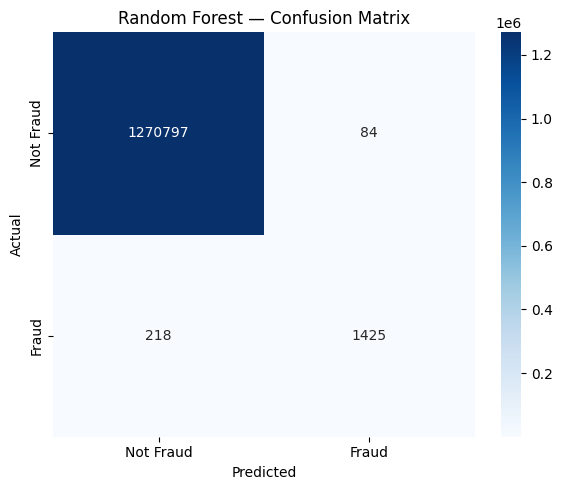

True Negatives  (correct non-fraud): 1,270,797
False Positives (false alarms)      : 84
False Negatives (missed fraud)      : 218
True Positives  (caught fraud)      : 1,425


In [29]:
# ─────────────────────────────────────────────
# CELL 28 — RF Evaluation on Test Set
# ─────────────────────────────────────────────

y_prob_test_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_test_rf = (y_prob_test_rf >= RF_BEST_THRESHOLD).astype(int)

evaluate_model(
    'Random Forest (Optimal Threshold)',
    y_test, y_pred_test_rf, y_prob_test_rf, RF_BEST_THRESHOLD
)

plot_confusion_matrix(y_test, y_pred_test_rf, 'Random Forest — Confusion Matrix')

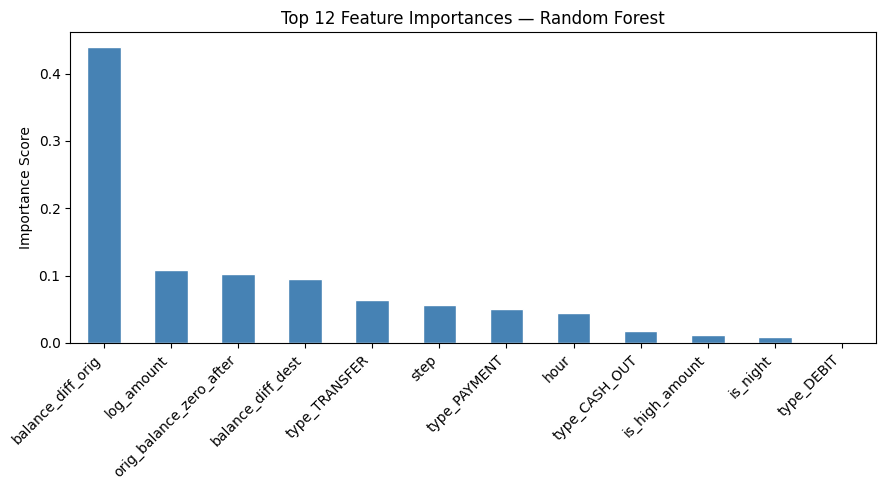

Top 5 most important features:
balance_diff_orig          0.439396
log_amount                 0.108276
orig_balance_zero_after    0.103069
balance_diff_dest          0.094478
type_TRANSFER              0.063933


In [30]:
# ─────────────────────────────────────────────
# CELL 29 — Feature Importance (Random Forest)
# ─────────────────────────────────────────────

feat_imp = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp.head(12).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 12 Feature Importances — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_imp.head(5).to_string())

### XGBoost Model

In [33]:
# ─────────────────────────────────────────────
# CELL 30 — XGBoost (Fastest model for large fraud data)
# ─────────────────────────────────────────────

neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos   # scale_pos_weight compensates for class imbalance
print(f'XGBoost scale_pos_weight: {spw:.1f}')

xgb_params = {
    'n_estimators'     : [300, 500],
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.05, 0.1, 0.15],
    'subsample'        : [0.8],
    'colsample_bytree' : [0.8],
    'reg_lambda'       : [0, 1, 5, 10]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='aucpr',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_params,
    n_iter=10,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    random_state=42
)

# XGBoost sample for search
X_xgb_sample, _, y_xgb_sample, _ = train_test_split(
    X_train, y_train,
    train_size=500_000,
    stratify=y_train,
    random_state=42
)

print('Fitting XGBoost with RandomizedSearchCV...')
xgb_search.fit(X_xgb_sample, y_xgb_sample)
print('Best XGB params:', xgb_search.best_params_)

# FIX: Build a fresh model from best_params_ with early_stopping_rounds
# (avoids the set_params-after-fit bug — refit overwrites tuned n_estimators)
best_xgb = xgb.XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=spw,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

print('Fitting XGBoost on full training set with early stopping...')
best_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

y_prob_test_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Threshold tuning on validation set
xgb_results = []
y_prob_val_xgb = best_xgb.predict_proba(X_val)[:, 1]
for t in np.arange(0.01, 0.99, 0.01):
    y_pred_t = (y_prob_val_xgb >= t).astype(int)
    xgb_results.append({
        'threshold': t,
        'f1'       : f1_score(y_val, y_pred_t, zero_division=0),
        'recall'   : recall_score(y_val, y_pred_t, zero_division=0),
        'precision': precision_score(y_val, y_pred_t, zero_division=0)
    })

xgb_thresh_df = pd.DataFrame(xgb_results)
best_xgb_row  = xgb_thresh_df.loc[xgb_thresh_df['f1'].idxmax()]
XGB_BEST_THRESHOLD = best_xgb_row['threshold']

print(f'Best XGB threshold: {XGB_BEST_THRESHOLD:.2f}')
print(f'  Precision: {best_xgb_row["precision"]:.4f}')
print(f'  Recall   : {best_xgb_row["recall"]:.4f}')
print(f'  F1       : {best_xgb_row["f1"]:.4f}')

y_pred_test_xgb = (y_prob_test_xgb >= XGB_BEST_THRESHOLD).astype(int)
evaluate_model('XGBoost (Optimal Threshold)', y_test, y_pred_test_xgb, y_prob_test_xgb, XGB_BEST_THRESHOLD)

joblib.dump(best_xgb, 'fraud_xgb_model.pkl')
print('XGB model saved → fraud_xgb_model.pkl')


XGBoost scale_pos_weight: 773.8
Fitting XGBoost with RandomizedSearchCV...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best XGB params: {'subsample': 0.8, 'reg_lambda': 5, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
[0]	validation_0-aucpr:0.31358
[1]	validation_0-aucpr:0.78963
[2]	validation_0-aucpr:0.80629
[3]	validation_0-aucpr:0.79819
[4]	validation_0-aucpr:0.78504
[5]	validation_0-aucpr:0.76098
[6]	validation_0-aucpr:0.82482
[7]	validation_0-aucpr:0.84086
[8]	validation_0-aucpr:0.83977
[9]	validation_0-aucpr:0.83960
[10]	validation_0-aucpr:0.83885
[11]	validation_0-aucpr:0.84478
[12]	validation_0-aucpr:0.83999
[13]	validation_0-aucpr:0.85758
[14]	validation_0-aucpr:0.86339
[15]	validation_0-aucpr:0.88015
[16]	validation_0-aucpr:0.87904
[17]	validation_0-aucpr:0.88437
[18]	validation_0-aucpr:0.88159
[19]	validation_0-aucpr:0.88154
[20]	validation_0-aucpr:0.88207
[21]	validation_0-aucpr:0.88131
[22]	validation_0-aucpr:0.88206
[

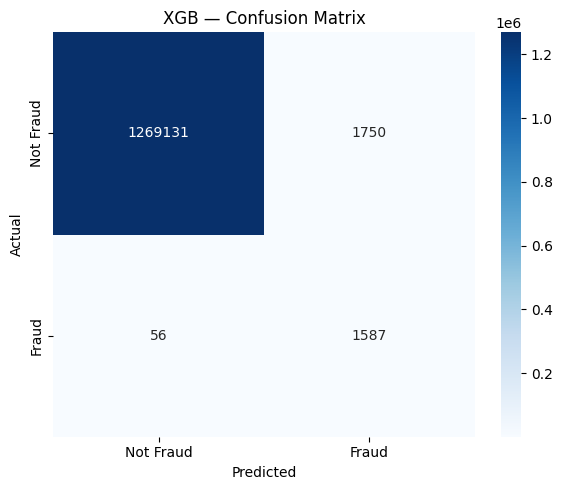

True Negatives  (correct non-fraud): 1,269,131
False Positives (false alarms)      : 1,750
False Negatives (missed fraud)      : 56
True Positives  (caught fraud)      : 1,587


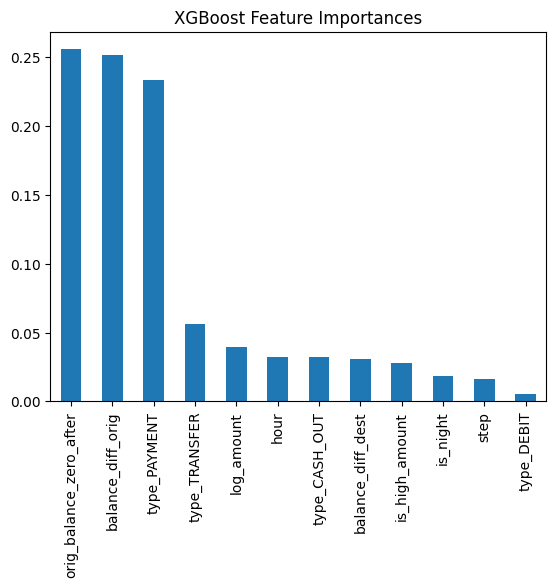

In [34]:
plot_confusion_matrix(
    y_test, y_pred_test_xgb, 'XGB — Confusion Matrix'
)

xgb_feat_imp = pd.Series(
best_xgb.feature_importances_,
index=X_train.columns
).sort_values(ascending=False)

xgb_feat_imp.head(12).plot(kind='bar')
plt.title('XGBoost Feature Importances')
plt.show()

### Model Comparison Summary

### Ensemble Model — RF + XGBoost Soft Voting

In [ ]:
# ─────────────────────────────────────────────
# CELL 34 — Ensemble: RF + XGBoost Soft Voting
# Why: RF (bagging) and XGBoost (boosting) fail on DIFFERENT samples.
#      Averaging their probabilities reduces variance and smooths
#      confident wrong predictions — critical for fraud detection.
#      LR excluded: it is a linear model whose signal is already
#      captured by both tree models, adding it only dilutes quality.
# ─────────────────────────────────────────────

# ── Step 1: Tune ensemble threshold on VALIDATION set ────────────
ens_val_probs = (
    best_rf.predict_proba(X_val)[:, 1] +
    best_xgb.predict_proba(X_val)[:, 1]
) / 2

ens_results = []
for t in np.arange(0.01, 0.99, 0.01):
    y_pred_t = (ens_val_probs >= t).astype(int)
    ens_results.append({
        'threshold': t,
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'recall'   : recall_score(y_val, y_pred_t, zero_division=0),
        'f1'       : f1_score(y_val, y_pred_t, zero_division=0)
    })

ens_thresh_df  = pd.DataFrame(ens_results)
best_ens_row   = ens_thresh_df.loc[ens_thresh_df['f1'].idxmax()]
ENS_THRESHOLD  = best_ens_row['threshold']

print(f'Best Ensemble threshold: {ENS_THRESHOLD:.2f}')
print(f'  Precision : {best_ens_row["precision"]:.4f}')
print(f'  Recall    : {best_ens_row["recall"]:.4f}')
print(f'  F1        : {best_ens_row["f1"]:.4f}')

# ── Step 2: Evaluate on TEST set ─────────────────────────────────
y_prob_test_ens = (
    y_prob_test_rf +
    y_prob_test_xgb
) / 2

y_pred_test_ens = (y_prob_test_ens >= ENS_THRESHOLD).astype(int)

evaluate_model(
    'Ensemble — RF + XGBoost Soft Vote (Optimal Threshold)',
    y_test, y_pred_test_ens, y_prob_test_ens, ENS_THRESHOLD
)
plot_confusion_matrix(y_test, y_pred_test_ens, 'Ensemble (RF + XGB) — Confusion Matrix')


### Full Model Comparison — All 4 Models

In [ ]:
# ─────────────────────────────────────────────
# CELL 35 — Full Comparison: LR vs RF vs XGB vs Ensemble
# Primary metric: AUPRC — best for imbalanced fraud data
# ─────────────────────────────────────────────

summary = []

summary.append({
    'Model'    : 'Logistic Regression',
    'Threshold': BEST_THRESHOLD,
    'Precision': precision_score(y_test, y_pred_test_lr,  zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_test_lr,     zero_division=0),
    'F1'       : f1_score(y_test, y_pred_test_lr,         zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_test_lr),
    'AUPRC'    : average_precision_score(y_test, y_prob_test_lr)
})

summary.append({
    'Model'    : 'Random Forest',
    'Threshold': RF_BEST_THRESHOLD,
    'Precision': precision_score(y_test, y_pred_test_rf,  zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_test_rf,     zero_division=0),
    'F1'       : f1_score(y_test, y_pred_test_rf,         zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_test_rf),
    'AUPRC'    : average_precision_score(y_test, y_prob_test_rf)
})

if XGB_AVAILABLE:
    summary.append({
        'Model'    : 'XGBoost',
        'Threshold': XGB_BEST_THRESHOLD,
        'Precision': precision_score(y_test, y_pred_test_xgb, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred_test_xgb,    zero_division=0),
        'F1'       : f1_score(y_test, y_pred_test_xgb,        zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob_test_xgb),
        'AUPRC'    : average_precision_score(y_test, y_prob_test_xgb)
    })

summary.append({
    'Model'    : 'Ensemble (RF + XGB)',
    'Threshold': ENS_THRESHOLD,
    'Precision': precision_score(y_test, y_pred_test_ens, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_test_ens,    zero_division=0),
    'F1'       : f1_score(y_test, y_pred_test_ens,        zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_test_ens),
    'AUPRC'    : average_precision_score(y_test, y_prob_test_ens)
})

summary_df = pd.DataFrame(summary).set_index('Model').round(4)

# Highlight best in each column
def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_best]

print('\n' + '='*70)
print('  FINAL MODEL COMPARISON — All 4 Models (Test Set)')
print('  Primary ranking metric: AUPRC  |  Secondary: F1')
print('='*70)
display(summary_df.style.apply(highlight_best))

best_auprc = summary_df['AUPRC'].idxmax()
best_f1    = summary_df['F1'].idxmax()
print(f'\n🏆 Best model by AUPRC : {best_auprc}  ({summary_df.loc[best_auprc, "AUPRC"]:.4f})')
print(f'🏆 Best model by F1    : {best_f1}  ({summary_df.loc[best_f1, "F1"]:.4f})')


In [ ]:
# ─────────────────────────────────────────────
# CELL 36 — Bar Chart: Key Metrics Across All Models
# ─────────────────────────────────────────────

metrics   = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'AUPRC']
models    = summary_df.index.tolist()
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']  # blue, orange, green, red
x         = np.arange(len(metrics))
bar_width = 0.18

fig, ax = plt.subplots(figsize=(13, 6))

for idx, (model, color) in enumerate(zip(models, colors)):
    vals = [summary_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + idx * bar_width, vals, bar_width,
                  label=model, color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x + bar_width * (len(models) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.35)
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# CELL 37 — Precision-Recall Curves: All 4 Models
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: Precision-Recall Curves ────────────
model_probs = [
    ('Logistic Regression', y_prob_test_lr,  '#4C72B0'),
    ('Random Forest',       y_prob_test_rf,  '#DD8452'),
    ('XGBoost',             y_prob_test_xgb, '#55A868'),
    ('Ensemble (RF+XGB)',   y_prob_test_ens, '#C44E52'),
]

for name, y_prob, color in model_probs:
    p, r, _ = precision_recall_curve(y_test, y_prob)
    auprc   = average_precision_score(y_test, y_prob)
    axes[0].plot(r, p, label=f'{name}  (AUPRC={auprc:.4f})', color=color, lw=2)

axes[0].axhline(y=y_test.mean(), color='black', linestyle='--', alpha=0.5,
                label=f'No-skill baseline ({y_test.mean():.4f})')
axes[0].set_xlabel('Recall', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8.5)
axes[0].grid(alpha=0.35)

# ── Right: ROC Curves ────────────────────────
for name, y_prob, color in model_probs:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name}  (AUC={auc:.4f})', color=color, lw=2)

axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8.5)
axes[1].grid(alpha=0.35)

plt.suptitle('All Models — Curve Comparison (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Which Score to Use for Each Model & Why

In [ ]:
# ─────────────────────────────────────────────
# CELL 38 — Score Guidance: Which Metric to Trust for Each Model
# ─────────────────────────────────────────────

score_guidance = """
╔══════════════════════════════════════════════════════════════════════════════╗
║           WHICH SCORE TO USE FOR EACH MODEL — AND WHY                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PRIMARY METRIC FOR ALL MODELS:  AUPRC  (Area Under Precision-Recall Curve) ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  Why AUPRC over ROC-AUC?                                                     ║
║  • Fraud is extremely imbalanced (~0.1% positive rate).                     ║
║  • ROC-AUC counts TRUE NEGATIVES — with 99.9% non-fraud, even a             ║
║    bad model scores ROC-AUC > 0.95 just by predicting mostly 0.             ║
║  • AUPRC focuses ONLY on the positive class (actual frauds).                ║
║    A random classifier scores AUPRC = fraud_rate ≈ 0.001.                  ║
║    Any real improvement from 0.001 is meaningful and measurable.            ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  MODEL               │ PRIMARY     │ SECONDARY  │ REASON                    ║
║  ────────────────────┼─────────────┼────────────┼───────────────────────    ║
║  Logistic Regression │ AUPRC       │ Recall     │ LR gives well-calibrated  ║
║                      │             │            │ probabilities, so AUPRC   ║
║                      │             │            │ is reliable. Prioritise   ║
║                      │             │            │ Recall: LR will miss      ║
║                      │             │            │ complex fraud patterns,   ║
║                      │             │            │ so catching more matters. ║
║  ────────────────────┼─────────────┼────────────┼───────────────────────    ║
║  Random Forest       │ AUPRC       │ F1         │ RF probabilities are      ║
║                      │             │            │ NOT well-calibrated       ║
║                      │             │            │ (trees output proportion  ║
║                      │             │            │ not true probability).    ║
║                      │             │            │ F1 at optimal threshold   ║
║                      │             │            │ is the honest scorecard.  ║
║  ────────────────────┼─────────────┼────────────┼───────────────────────    ║
║  XGBoost             │ AUPRC       │ F1         │ Same calibration caveat   ║
║                      │             │            │ as RF. XGB with           ║
║                      │             │            │ eval_metric=aucpr is      ║
║                      │             │            │ trained to maximise AUPRC ║
║                      │             │            │ directly — so that is     ║
║                      │             │            │ the most honest measure.  ║
║  ────────────────────┼─────────────┼────────────┼───────────────────────    ║
║  Ensemble (RF+XGB)   │ AUPRC       │ F1         │ Averaging probs smooths   ║
║                      │             │            │ calibration somewhat.     ║
║                      │             │            │ AUPRC rewards consistent  ║
║                      │             │            │ high-precision recall     ║
║                      │             │            │ across all thresholds —   ║
║                      │             │            │ ideal for soft voting.    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  BUSINESS CONTEXT OVERRIDE                                                   ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  If cost of MISSING fraud >> cost of FALSE ALARM:  maximise RECALL           ║
║  If false alarms hurt customer experience badly:   maximise PRECISION        ║
║  If both costs are roughly equal:                  maximise F1               ║
║  For model SELECTION & TUNING always use:          AUPRC                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  METRICS THAT ARE MISLEADING FOR THIS DATASET                                ║
║  ─────────────────────────────────────────────────────────────────────────── ║
║  Accuracy  → useless  (predicting all-0 gives 99.9% accuracy)               ║
║  ROC-AUC   → inflated (high TN count masks poor fraud detection)            ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(score_guidance)

# Print actual AUPRC scores for easy reference
print("  AUPRC Leaderboard (higher = better, baseline ≈ fraud rate):")
print("  " + "-"*45)
auprc_series = summary_df['AUPRC'].sort_values(ascending=False)
for rank, (model, score) in enumerate(auprc_series.items(), 1):
    bar = "█" * int(score * 40)
    print(f"  #{rank}  {model:<22}  {score:.4f}  {bar}")


In [ ]:
# ─────────────────────────────────────────────
# CELL 39 — Saved Files Summary
# ─────────────────────────────────────────────

saved_files = [
    'fraud_scaler.pkl',
    'fraud_lr_model.pkl',
    'fraud_rf_model.pkl',
]
if XGB_AVAILABLE:
    saved_files.append('fraud_xgb_model.pkl')

print('Saved artifacts:')
for f in saved_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) / 1024 if exists else 0
    print(f'  {f:30s}  {"✅" if exists else "❌"}  {size:.1f} KB')

print()
print('Recommended production model: Ensemble (RF + XGBoost)')
print('Primary evaluation metric   : AUPRC')
print()
print('To load and run ensemble in production:')
print('''
  import joblib, numpy as np
  scaler   = joblib.load("fraud_scaler.pkl")
  rf_model = joblib.load("fraud_rf_model.pkl")
  xgb_model= joblib.load("fraud_xgb_model.pkl")

  X_new_scaled = scaler.transform(X_new[num_cols])
  prob_rf      = rf_model.predict_proba(X_new_scaled)[:, 1]
  prob_xgb     = xgb_model.predict_proba(X_new_scaled)[:, 1]
  prob_ens     = (prob_rf + prob_xgb) / 2

  # Use ENS_THRESHOLD tuned on validation set
  prediction   = (prob_ens >= ENS_THRESHOLD).astype(int)
''')
